In [2]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Load Data
df_songs = pd.read_csv("C:/fiifi/Shatta_Analytics_Project/Python_files/python_data_analysis/songs_fact.csv", index_col=0)
df_metrics = pd.read_csv("C:/fiifi/Shatta_Analytics_Project/Python_files/python_data_analysis/platform_metrics_dim.csv", index_col=0)

In [8]:
# Filter df_metrics for only YouTube
df_youtube = df_metrics[df_metrics["platform_name"] == "YouTube"].copy()

# Merge df_youtube & df_songs
df_merged = df_songs.merge(df_youtube, on="song_id", how="inner")

# Drop release_date_original and release_date_original.1
df_merged = df_merged.drop(columns=["release_date_original", "release_date_original.1"])

# Convert release_date  to datetime
df_merged["release_date"] = pd.to_datetime(df_merged["release_date"], dayfirst=False, errors="coerce")

# Calculate song age in days(as of current date/ reference date)
reference_date = datetime.now()
df_merged["song_age_days"] = (reference_date - df_merged["release_date"]).dt.days

# Remove songs with invalid release dates or negative age
df_merged = df_merged[df_merged["song_age_days"] >= 0].copy()

In [12]:
# Calculate the average views per day since release
df_merged["views_per_day"] = round(df_merged["views"] / df_merged["song_age_days"], 0)

In [37]:
# Find post release spikes
# Criteria for a spike
# 1. Song is at least 30 days old
# 2. Views per day >5,000
# 3. Sort by highest views per day

spike_candidates = df_merged[(df_merged["song_age_days"] >= 30) & (df_merged["views_per_day"] > 5000)].copy()

spike_candidates = spike_candidates.sort_values("views_per_day", ascending=False)

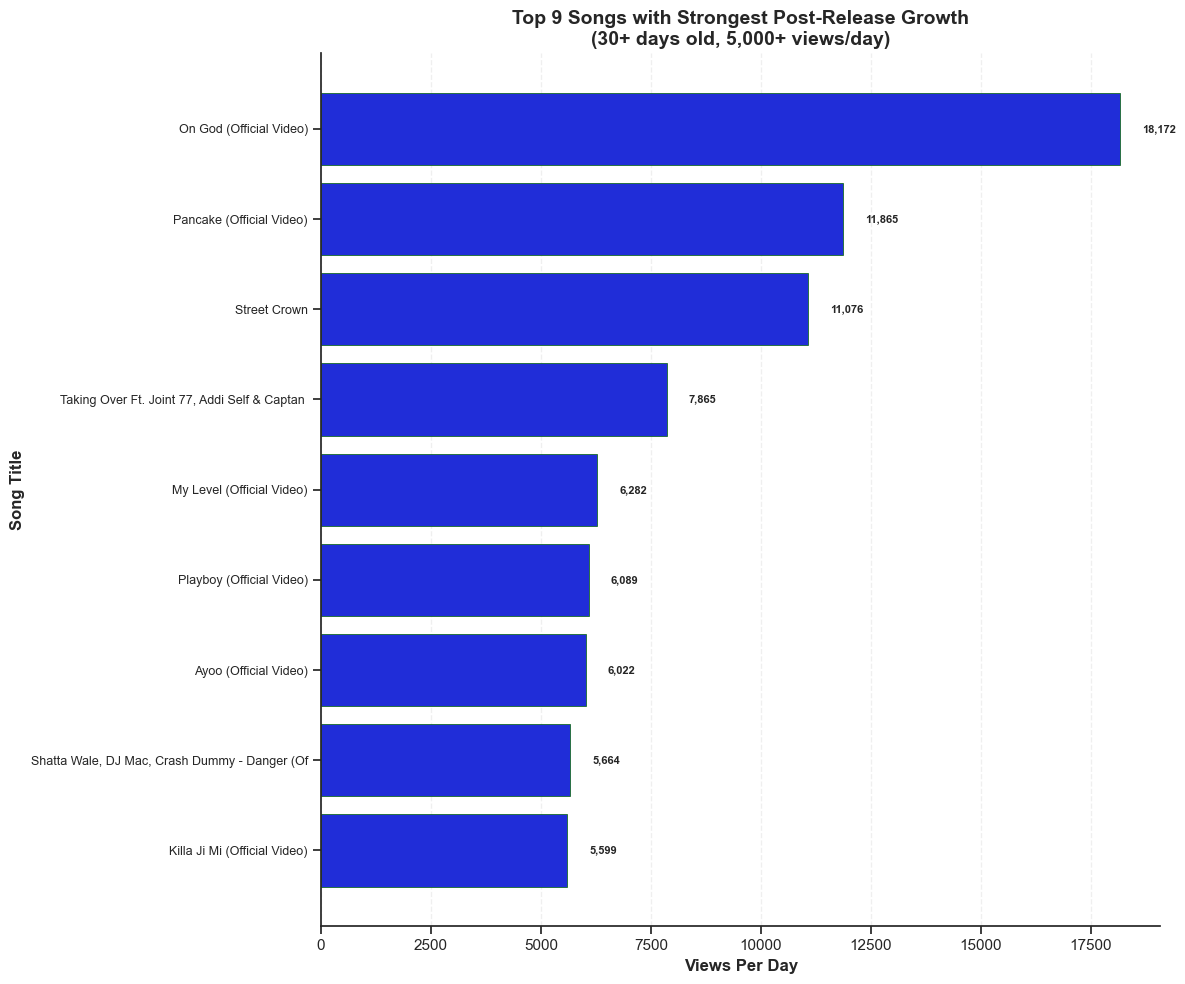

In [42]:
# Take top 15 for cleaner visualization (adjust as needed)
top_spikes = spike_candidates.head(15).copy()

# Clean up titles for better display (truncate if too long)
top_spikes['title_clean'] = top_spikes['title'].str[:45]  # Limit to 45 characters

# Sort ascending for horizontal bar chart (best on top)
top_spikes = top_spikes.sort_values('views_per_day', ascending=True)

# ============================================
# CREATE HORIZONTAL BAR CHART
# ============================================

plt.figure(figsize=(12, 10))

# Create horizontal bars
bars = plt.barh(
    range(len(top_spikes)),
    top_spikes['views_per_day'].values,
    color="#202dd8",
    edgecolor='darkgreen',
    linewidth=0.5
)

# Add song titles as y-axis labels
plt.yticks(
    range(len(top_spikes)),
    top_spikes['title_clean'].values,
    fontsize=9
)

# Labels and title
plt.xlabel('Views Per Day', fontsize=12, fontweight='bold')
plt.ylabel('Song Title', fontsize=12, fontweight='bold')
plt.title(
    f'Top {len(top_spikes)} Songs with Strongest Post-Release Growth\n(30+ days old, 5,000+ views/day)',
    fontsize=14,
    fontweight='bold'
)

# Add value labels at the end of each bar
for i, (bar, val) in enumerate(zip(bars, top_spikes['views_per_day'])):
    plt.text(
        val + 500,  # Position slightly after the bar end
        i,
        f'{val:,.0f}',
        va='center',
        fontsize=8,
        fontweight='bold'
    )

# Add grid for better readability
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()